In [1]:
import tensorflow as tf # version 2.18
import sklearn
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.python import keras
from keras import layers, callbacks, models # from tensorflow.keras
from keras import preprocessing
from keras import optimizers
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import numpy as np
from sklearn.compose import make_column_selector




plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large', titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

np.random.seed(31415)
tf.random.set_seed(31415)
os.environ["PYTHONHASHSEED"] = str(31415)
warnings.filterwarnings("ignore") 

In [2]:
data = pd.read_csv('./Data/merged.csv', index_col=0)
data=data[(data['TEMP_MAX']!=0.0) & (data['NDVI']!=-1)]
data = data.dropna(subset=['NDVI'])
data.drop(['AVG_100M_WIND', 'YEAR', 'CLOUD_HIGH', 'CLOUD_MID', 'CLOUD', 'AVG_WEATHER_CONDITION', 'APPARENT_TEMP', 'TEMP_MIN', 'AVG_PRECIPITATION'], axis=1, inplace=True)
X = data.copy()
X = X.dropna(subset=['fire'])
X = X.sample(frac=1, random_state=42)
y = X['fire']
X = X.drop(columns=['fire'])
X.head()

,LATDD83,LONGDD83,MONTH,DAY,TEMP_MAX,AVG_RELATIVE_HUMIDITY,AVG_10M_WIND,CLOUD_LOW,AVG_SOIL_TEMP,AVG_SOIL_MOISTURE,ELEVATION,NDVI
19413,43.624960,-85.735840,3,23,68.496796,59.049397,10.063561,4.166667,49.836803,0.201208,282.0,0.4311
30393,47.182760,-110.975231,1,3,28.672701,67.719688,13.186325,2.875000,31.695200,0.350292,1477.0,0.2159
22201,46.839145,-114.491847,8,28,67.800201,66.179832,6.172151,9.083333,52.061451,0.261833,1586.0,0.7884
27006,47.610547,-113.733942,10,22,65.321602,69.686638,5.376391,1.166667,44.910351,0.246875,1143.0,0.6762
21667,44.420482,-118.728332,5,26,66.759796,53.958355,5.682009,4.708333,57.913548,0.245333,1125.0,0.4643


In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

In [4]:
X.dtypes

LATDD83                  float64
LONGDD83                 float64
MONTH                      int64
DAY                        int64
TEMP_MAX                 float64
AVG_RELATIVE_HUMIDITY    float64
AVG_10M_WIND             float64
CLOUD_LOW                float64
AVG_SOIL_TEMP            float64
AVG_SOIL_MOISTURE        float64
ELEVATION                float64
NDVI                     float64
dtype: object

In [5]:
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object', 'category']).columns
preprocessor = make_column_transformer(
    (
        make_pipeline(
            SimpleImputer(strategy='constant', fill_value=0),
            StandardScaler()
        ),
        make_column_selector(dtype_include=['int64', 'float64'])
    ),
    (
        make_pipeline(
            SimpleImputer(strategy='constant', fill_value='NA'),
            OneHotEncoder(handle_unknown='ignore')
        ),
        make_column_selector(dtype_include=['object', 'category'])
    )
)
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

In [6]:
model = models.Sequential([
    layers.BatchNormalization(input_shape = [X_train.shape[1]]),
    layers.Dense(units=256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(units=256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(units=256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(units=256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(units=1, activation='sigmoid')
])

In [7]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=25, restore_best_weights=True)

Epoch 1/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - binary_accuracy: 0.7167 - loss: 0.6023 - val_binary_accuracy: 0.7383 - val_loss: 0.6115
Epoch 2/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.7477 - loss: 0.5253 - val_binary_accuracy: 0.7192 - val_loss: 0.5752
Epoch 3/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7581 - loss: 0.5016 - val_binary_accuracy: 0.7553 - val_loss: 0.5380
Epoch 4/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7639 - loss: 0.4908 - val_binary_accuracy: 0.7784 - val_loss: 0.5048
Epoch 5/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7706 - loss: 0.4803 - val_binary_accuracy: 0.7900 - val_loss: 0.4704
Epoch 6/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7744 - loss: 0.4731 - val_binary_accuracy: 0.7928 - val_loss: 0.4572
Epoch 7/300
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7767 - loss: 0.4710 - val_binary_accuracy: 0.7948 - val_loss: 0.4466
Epoch 8/300
6

<Axes: title={'center': 'Training vs Validation Accuracy'}>

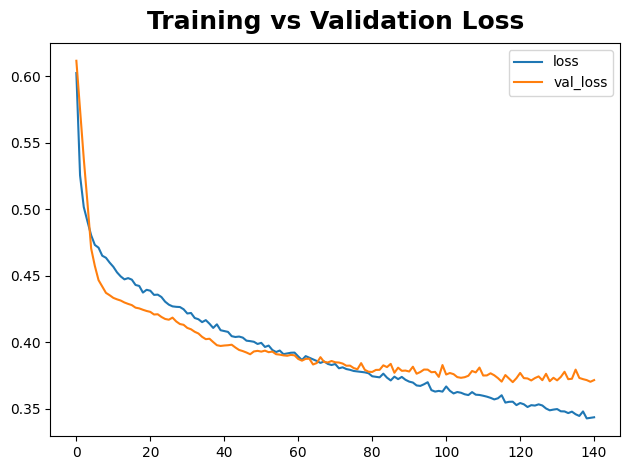

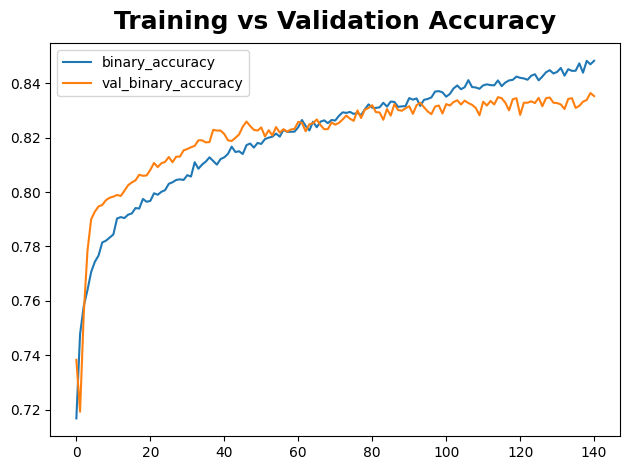

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=300,
    callbacks=[early_stopping]
)

history_df = pd.DataFrame(history.history)

history_df[['loss', 'val_loss']].plot(title='Training vs Validation Loss')
history_df[['binary_accuracy', 'val_binary_accuracy']].plot(title='Training vs Validation Accuracy')

In [9]:
from sklearn.feature_selection import mutual_info_regression

def get_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(['category', 'object']):
        X[colname], _ = X[colname].factorize()
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    scores = pd.Series(scores, name='mi_scores', index=X.columns)
    scores = scores.sort_values(ascending=False)
    return scores

get_mi_scores(X, y)

NDVI                     0.135288
TEMP_MAX                 0.097981
MONTH                    0.088254
AVG_SOIL_TEMP            0.084095
LONGDD83                 0.081404
AVG_SOIL_MOISTURE        0.060252
LATDD83                  0.047946
AVG_10M_WIND             0.041555
DAY                      0.034818
AVG_RELATIVE_HUMIDITY    0.031571
CLOUD_LOW                0.030422
ELEVATION                0.015271
Name: mi_scores, dtype: float64

In [10]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_valid) 
y_pred = (y_pred >= 0.5).astype(int)

print(classification_report(y_valid, y_pred))

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      3992
           1       0.81      0.87      0.84      3818

    accuracy                           0.83      7810
   macro avg       0.84      0.84      0.83      7810
weighted avg       0.84      0.83      0.83      7810

